In [1]:
import ROOT

import genie_loader
from importlib import reload
reload(genie_loader)
from genie_loader import *

Welcome to JupyROOT 6.28/10


In [2]:
det_width=39 #m
det_height=13.8 #m
cut_extend=1 #m

det_half_width = 19.5

In [4]:
GENIE_OUTPUT_DIR="/project/6075887/MATHUSLA/simulation/genie/genie_output_2025_10"
neutrino_sims =["genie_output_atmos"]

filename = f"{GENIE_OUTPUT_DIR}/{neutrino_sims[0]}/gntp.1.gtrac.root"

In [5]:

tfile=ROOT.TFile(filename)
tree_name = tfile.GetListOfKeys()[0].GetName()
Tree = tfile.Get(tree_name)
entries = Tree.GetEntries()
branches = [Tree.GetListOfBranches()[i].GetName() for i in range(len(Tree.GetListOfBranches()))]
tfile.ls()
print(entries, branches)

468420 ['EvtFlags', 'EvtCode', 'EvtNum', 'EvtXSec', 'EvtDXSec', 'EvtKPS', 'EvtWght', 'EvtProb', 'EvtVtx', 'StdHepN', 'StdHepPdg', 'StdHepStatus', 'StdHepRescat', 'StdHepX4', 'StdHepP4', 'StdHepPolz', 'StdHepFd', 'StdHepLd', 'StdHepFm', 'StdHepLm']
TFile**		/project/6075887/MATHUSLA/simulation/genie/genie_output_2025_10/genie_output_atmos/gntp.1.gtrac.root	
 TFile*		/project/6075887/MATHUSLA/simulation/genie/genie_output_2025_10/genie_output_atmos/gntp.1.gtrac.root	
  OBJ: TTree	gRooTracker	GENIE event tree rootracker format : 0 at: 0x55ea21ebf4e0
  KEY: TTree	gRooTracker;9	GENIE event tree rootracker format [current cycle]
  KEY: TTree	gRooTracker;8	GENIE event tree rootracker format [backup cycle]


In [6]:
vertices=[]
for i in tqdm(range(entries)):
    Tree.GetEntry(i)    
    vertices.append(list(Tree.EvtVtx))
vertices=np.array(vertices)

100%|██████████| 468420/468420 [00:09<00:00, 50114.74it/s]


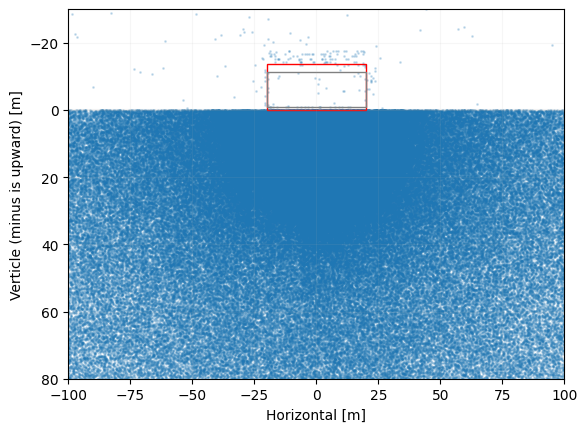

In [10]:
plt.scatter(vertices[:,0], vertices[:,2], s=1, alpha=0.2)
plt.gca().add_patch(patch.Rectangle((-20,-det_height), 40,det_height, edgecolor='r', facecolor='none'))
plt.gca().add_patch(patch.Rectangle((-20,-det_height+2.4), 40,det_height-3.2, edgecolor='grey', facecolor='none'))
plt.xlim(-100,100)
plt.ylim(-30,80)
plt.gca().invert_yaxis()
plt.axhline(0,color="grey", alpha=0.1)
plt.xlabel("Horizontal [m]")
plt.ylabel("Verticle (minus is upward) [m]")
plt.grid(alpha=0.1)
# plt.axhline(-85.47)

# Select events in the red box and merged to a ROOT file

In [8]:
import simhelper.root as iroot

In [11]:

def process_run(i_run):
    filename_output = f"{GENIE_OUTPUT_DIR}/genie_output_atmos/run_{i_run}_source.root"
    
    #-----------------------------
    # setup output file
    if not os.path.exists(os.path.dirname(filename_output)):
        Path(os.path.dirname(filename_output)).mkdir( parents=True, exist_ok=True )
    tree_writer = iroot.tfile_writer("data", filename_output)
    tree_writer.define_branch("Gen_pdgID", 'vector<double>')    
    tree_writer.define_branch("Gen_x", 'vector<float>')    
    tree_writer.define_branch("Gen_y", 'vector<float>')    
    tree_writer.define_branch("Gen_z", 'vector<float>')    
    tree_writer.define_branch("Gen_t", 'vector<float>')    
    tree_writer.define_branch("Gen_px", 'vector<float>')    
    tree_writer.define_branch("Gen_py", 'vector<float>')    
    tree_writer.define_branch("Gen_pz", 'vector<float>')       
    
    #-----------------------------
    # Loop all simulations in a run
    vertex_selected={}
    filename = f"{GENIE_OUTPUT_DIR}/genie_output_atmos/gntp.{i_run}.gtrac.root"
    tfile=ROOT.TFile(filename)
    tree_name = tfile.GetListOfKeys()[0].GetName()
    Tree = tfile.Get(tree_name)
    entries = Tree.GetEntries()
    branches = [Tree.GetListOfBranches()[i].GetName() for i in range(len(Tree.GetListOfBranches()))]
    # tfile.ls()
    # print(entries, branches)


    # Loop all entries
    for i in range(entries):
        Tree.GetEntry(i)   
    
        # Get the vertex location
        vertex=list(Tree.EvtVtx) # (x, y, z, t) of vertex (in SI)
        x,y,z,t = vertex
    
        # Only select those within the detector volume plus a little edge
        if (abs(x)<det_width/2+cut_extend)  &  (abs(y)<det_width/2+cut_extend)  & (-z>-cut_extend) & (-z<det_height+cut_extend):
            # Only read the final state particles in this event
            p4s, pdgs = get_final(Tree)           
            # Get event info
            evtcode=str(Tree.EvtCode).split(";") # Example: 'nu:14;tgt:1000080160;N:2112;proc:Weak[CC],QES;'
            parent_pdg=int(evtcode[0].split(":")[1])
    
            # add back the detector offset
            # xx,yy,zz=y*1000, (-z+85.47)*1000, (x+90)*1000 # Convert to CMS coordinate (wrong)
            xx,yy,zz=x*1000, y*1000, -z*1000
            vertex_selected[i]=[[parent_pdg, xx,yy,zz, 0,0,0, 0]]
            for iparticle in range(len(p4s)):
                p4=p4s[iparticle]
                pdg=pdgs[iparticle]
                # Remove the pdgs of Nuclear codes
                if abs(pdg)<10000:
                    vertex_selected[i].append([pdg, xx,yy,zz, p4[0]*1000, p4[1]*1000, -p4[2]*1000, 0])    
    
    for key in vertex_selected:
        decay = vertex_selected[key]
        keys = ["Gen_pdgID","Gen_x","Gen_y","Gen_z","Gen_t","Gen_px","Gen_py","Gen_pz"]
        data = {key: [] for key in keys}
        for particle in decay:
            data["Gen_pdgID"].append(particle[0])
            data["Gen_x"].append(particle[1])
            data["Gen_y"].append(particle[2])
            data["Gen_z"].append(particle[3])
            data["Gen_t"].append(0)
            data["Gen_px"].append(particle[4])
            data["Gen_py"].append(particle[5])
            data["Gen_pz"].append(particle[6])
        tree_writer.fill(data)             
    tree_writer.write_and_close()            
    print("Events selected: ", len(vertex_selected.keys()))

    return vertex_selected

i_run = 1

vertex_selected = process_run(i_run)

Events selected:  1288


In [12]:
for i_run in range(1,100):
    print("Run", i_run, end=". ")
    try:
        process_run(i_run)
    except:
        print("  Run failed")

Run 1. Events selected:  1288
Run 2. Events selected:  1241
Run 3. Events selected:  1282
Run 4. Events selected:  1284
Run 5. Events selected:  1295
Run 6. Events selected:  1263
Run 7. Events selected:  1327
Run 8. Events selected:  1266
Run 9. Events selected:  1281
Run 10. Events selected:  1348
Run 11. Events selected:  1215
Run 12. Events selected:  1237
Run 13. Events selected:  1286
Run 14. Events selected:  1328
Run 15. Events selected:  1266
Run 16. Events selected:  1282
Run 17. Events selected:  1259
Run 18. Events selected:  1329
Run 19. Events selected:  1228
Run 20. Events selected:  1274
Run 21. Events selected:  1277
Run 22. Events selected:  1232
Run 23. Events selected:  1226
Run 24. Events selected:  1197
Run 25. Events selected:  1283
Run 26. Events selected:  1311
Run 27. Events selected:  1371
Run 28. Events selected:  1272
Run 29. Events selected:  1249
Run 30. Events selected:  1209
Run 31. Events selected:  1300
Run 32. Events selected:  1272
Run 33. Events se

# Check the simulation input

In [6]:
filename = "/project/6075887/MATHUSLA/simulation/genie/genie_output_2025_10/merged/run_1_source.root "

In [7]:
tfile=ROOT.TFile(filename)
tree_name = tfile.GetListOfKeys()[0].GetName()
Tree = tfile.Get(tree_name)
entries = Tree.GetEntries()
branches = [Tree.GetListOfBranches()[i].GetName() for i in range(len(Tree.GetListOfBranches()))]
tfile.ls()
print(entries, branches)

5866 ['Gen_pdgID', 'Gen_x', 'Gen_y', 'Gen_z', 'Gen_t', 'Gen_px', 'Gen_py', 'Gen_pz']
TFile**		/project/6075887/MATHUSLA/simulation/genie/genie_output_2025_10/merged/run_1_source.root	
 TFile*		/project/6075887/MATHUSLA/simulation/genie/genie_output_2025_10/merged/run_1_source.root	
  OBJ: TTree	data	Tree created by RootTreeWriter : 0 at: 0x5560e3a4e210
  KEY: TTree	data;1	Tree created by RootTreeWriter


In [ ]:
xs,ys,zs = [],[],[]
for i in range(Tree.GetEntries()):
    Tree.GetEntry(i)
    xs.append(Tree.Gen_x[0])
    ys.append(Tree.Gen_y[0])
    zs.append(Tree.Gen_z[0])

In [18]:
xs = np.array(xs)
ys = np.array(ys)
zs = np.array(zs)


In [ ]:
plt.scatter(xs*.001, zs*0.001, s=1, alpha=0.2)
plt.gca().add_patch(patch.Rectangle((-20,1), 40,det_height-1.2, edgecolor='r', facecolor='none'))
plt.xlim(-30,30)
plt.ylim(-5,20)
plt.axhline(0,color="grey", alpha=0.1)
plt.xlabel("Horizontal [m]")
plt.ylabel("Verticle [m]")
plt.grid(alpha=0.1)
# plt.axhline(-85.47)